<h1>Chapter 5 - Text Embeddings</h1>
<i>Generate embeddings for text and images that captures the meaning of it.</i>

<a href="https://learning.oreilly.com/library/view/rag-with-python/9798341600553/"><img src="https://img.shields.io/badge/O'Reilly-white.svg?logo=data:image/svg%2bxml;base64,PHN2ZyB3aWR0aD0iMzQiIGhlaWdodD0iMjciIHZpZXdCb3g9IjAgMCAzNCAyNyIgZmlsbD0ibm9uZSIgeG1sbnM9Imh0dHA6Ly93d3cudzMub3JnLzIwMDAvc3ZnIj4KPGNpcmNsZSBjeD0iMTMiIGN5PSIxNCIgcj0iMTEiIHN0cm9rZT0iI0Q0MDEwMSIgc3Ryb2tlLXdpZHRoPSI0Ii8+CjxjaXJjbGUgY3g9IjMwLjUiIGN5PSIzLjUiIHI9IjMuNSIgZmlsbD0iI0Q0MDEwMSIvPgo8L3N2Zz4K"></a>
<a href="https://github.com/polzerdo55862/RAG-with-Python-Cookbook"><img src="https://img.shields.io/badge/GitHub%20Repository-black?logo=github"></a>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polzerdo55862/RAG-with-Python-Cookbook/blob/main/ch05_text_embedding/text_embeddings.ipynb)

---

This notebook is for Chapter 5 of the [RAG with Python Cookbook](https://learning.oreilly.com/library/view/rag-with-python/9798341600553/) book by [Dominik Polzer](https://www.linkedin.com/in/polzerdo/).

---

<a href="https://learning.oreilly.com/library/view/rag-with-python/9798341600553/">
  <img src="https://raw.githubusercontent.com/polzerdo55862/RAG-with-Python-Cookbook/main/rag_cookbook.png" width="350" />
</a>


In [ ]:
!pip install sentence-transformers==4.1.0
!pip install requests==2.32.3
!pip install matplotlib==3.10.3
!pip install openai==1.79.0
!pip install langchain-openai==0.3.17
!pip install pandas==2.2.3
!pip install rank-bm25
!pip install langchain_text_splitters
!pip install openai==1.83.0
!pip install PyPDF2==3.0.1

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached filelock-3.24.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.2.19-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Usi

### Load sample files

This notebook uses sample Word and PDF files.

When running the notebook on Google Colab, uncomment the code below to download the `datasets` directory from the Github repo.

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone --no-checkout https://github.com/polzerdo55862/RAG-with-Python-Cookbook.git
    %cd RAG-with-Python-Cookbook
    !git sparse-checkout init --cone
    !git sparse-checkout set datasets
    !git checkout
    !cp -r datasets /content/datasets
    print("\u2713 Datasets downloaded to /content/datasets")
else:
    print("\u26a0 Running locally. Using ../datasets/ directory")

Cloning into 'RAG-with-Python-Cookbook'...
remote: Enumerating objects: 1649, done.
remote: Counting objects: 100% (389/389), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 1649 (delta 257), reused 249 (delta 190), pack-reused 1260 (from 2)
Receiving objects: 100% (1649/1649), 42.81 MiB | 10.92 MiB/s, done.
Resolving deltas: 100% (941/941), done.
/content/RAG-with-Python-Cookbook
Updating files: 100% (88/88), done.
Your branch is up to date with 'origin/main'.
✓ Datasets downloaded to /content/datasets


### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the secrets and access it by

In [ ]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

### How to generate embeddings using the OpenAI and HuggingFace API

In [ ]:
from openai import OpenAI

text_chunks = ["The sky is blue.", "The grass is green."]

client = OpenAI()  # uses the environment variable OPENAI_API_KEY

embeddings_list = []

for text_chunk in text_chunks:
    response = client.embeddings.create(
        input=[text_chunk], model="text-embedding-3-small"
    )
    embedding = response.data[0].embedding
    embeddings_list.append(embedding)

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
embeddings_langchain_list = []

for text_chunk in text_chunks:
    embeddings_openai_langchain = embeddings.embed_query(text_chunk)
    embeddings_langchain_list.append(embeddings_openai_langchain)

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
text_chunks = ["The sky is blue.", "The grass is green."]

embeddings = model.encode(text_chunks)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Calculating the Distance Between Embeddings

In [ ]:
import numpy as np
from numpy.linalg import norm
import pandas as pd
import os
from openai import OpenAI

text_chunks = [
    "The Great Fire of London in 1666 destroyed over 13,000 houses.",
    "Julius Caesar was assassinated on the Ides of March (March 15) in 44 BCE.",
    "The Black Death is estimated to have killed nearly one-third of the population.",
]

users_question = "Tell me something interesting about diseases in history"

embeddings_df = pd.DataFrame(text_chunks, columns=["text_chunk"])

client = OpenAI()
embeddings = []

def create_embeddings(text_chunk, client):
    embedding = (
        client.embeddings.create(input=[text_chunk], model="text-embedding-3-small")
        .data[0]
        .embedding
    )
    return embedding

# Apply function create_embeddings to the correct column
embeddings_df["embedding"] = embeddings_df["text_chunk"].apply(
    create_embeddings, client=client
)

users_question_embedding = create_embeddings(
    text_chunk=users_question, client=client
)

In [ ]:
# create a list to store the calculated cosine similarity
cos_sim = []

def calculate_cosine_similarity(text_chunk_embedding, users_question_embedding):
    A = text_chunk_embedding
    B = users_question_embedding

    # calculate the cosine similarity
    cosine = np.dot(A, B) / (norm(A) * norm(B))
    return cosine

# Apply function calculate_cosine_similarity to the correct column
embeddings_df["similarity"] = embeddings_df["embedding"].apply(
    calculate_cosine_similarity, users_question_embedding=users_question_embedding
)

In [ ]:
from sentence_transformers.util import cos_sim

document_embeddings=embeddings_df["embedding"].tolist()
query_embedding=embeddings_df["embedding"].tolist()

for document_embedding in document_embeddings:
    # Compute cosine_similarity between documents and query
    scores = cos_sim(document_embedding, query_embedding)

scores

tensor([[0.3404, 0.2003, 1.0000]])

### How to reduce the dimensionality of embeddings to be able to plot them

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from openai import OpenAI

# Define text chunks
text_chunks = [
    "The sky is blue.",
    "The sun is shining.",
    "I love chocolate.",
    "Ice cream is delicious.",
    "Roses are red.",
    "Violets are blue.",
]

# Initialize OpenAI client
# Assumes the OPENAI_API_KEY environment variable is set
client = OpenAI()
embeddings = []

# Generate embeddings for text chunks
for text_chunk in text_chunks:
    response = client.embeddings.create(
        input=[text_chunk], model="text-embedding-3-small"
    )
    embeddings.append(response.data[0].embedding)

# Convert embeddings to a DataFrame
# Each row represents one text chunk, each column one embedding dimension
embeddings_df = pd.DataFrame(
    embeddings, columns=[f"dim_{i}" for i in range(len(embeddings[0]))]
)

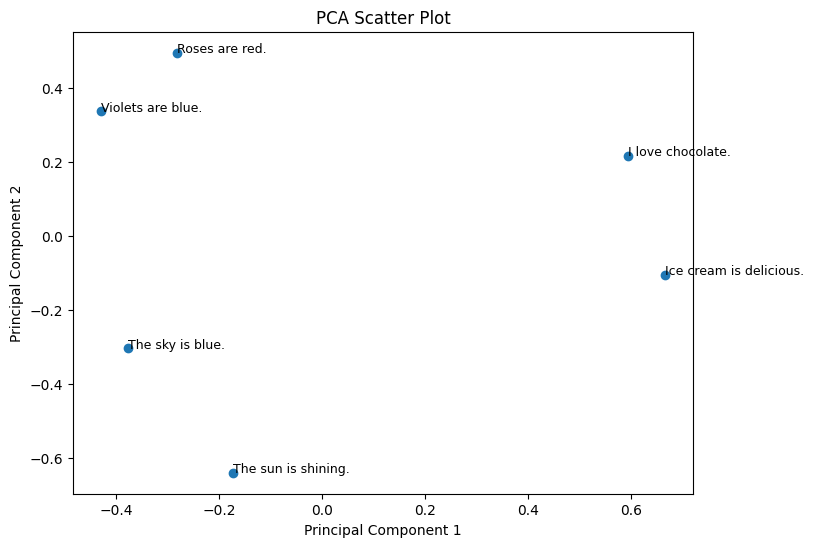

In [ ]:
# Perform PCA with 2 components
pca = PCA(n_components=2)
df_reduced = pca.fit_transform(embeddings_df)

# Create a new DataFrame with reduced dimensions
df_reduced = pd.DataFrame(df_reduced, columns=["PC1", "PC2"])
df_reduced["text"] = text_chunks  # Add original text chunks for labeling

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_reduced["PC1"], df_reduced["PC2"])

# Add labels to each point
for i, label in enumerate(df_reduced["text"]):
    plt.text(df_reduced["PC1"][i], df_reduced["PC2"][i], label, fontsize=9)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")

# Save the plot
plt.savefig("../principal_component_plot.svg", format="svg")

### How to calculate multimodal embeddings using CLIP

In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# Load the model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Text and image inputs
descriptions = ["A photo of a cat", "A photo of a dog"]
images = [
    Image.open("../datasets/images/cat.jpg"),
    Image.open("../datasets/images/dog.jpg"),
]

# Disable gradient tracking since this code only runs inference
with torch.no_grad():
    inputs = processor(
        text=descriptions,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
    )
    outputs = model(**inputs)

dot_products_per_text = outputs.logits_per_text

# Calculate probabilities
probabilities = dot_products_per_text.softmax(dim=1)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
print(probabilities)

print("Probability that the first image is a cat:", probabilities[0][0].item())
print("Probability that the second image is a dog:", probabilities[1][1].item())

tensor([[9.9995e-01, 5.3789e-05],
        [1.2071e-01, 8.7929e-01]])
Probability that the first image is a cat: 0.9999462366104126
Probability that the second image is a dog: 0.8792927861213684


### How to optimize similarity search by combining similarity search and keyword search

In [ ]:
from rank_bm25 import BM25Okapi
import pandas as pd

text_chunks = [
    "The Great Fire of London in 1666 destroyed over 13,000 houses.",
    "Julius Caesar was assassinated on the Ides of March (March 15) in 44 BCE.",
    "The Black Death is estimated to have killed nearly one-third of the European population.",
]

# Tokenize text into words
tokenized_chunks = [chunk.split(" ") for chunk in text_chunks]

bm25 = BM25Okapi(tokenized_chunks)

user_query = "Tell me something interesting about diseases in history"
tokenized_query = user_query.split(" ")

# BM25 scores for each document
bm25_scores = bm25.get_scores(tokenized_query)

# Document IDs ordered by keyword relevance (best first)
ranking_keyword_search = (
    pd.DataFrame(bm25_scores, columns=["score"])
    .sort_values(by="score", ascending=False)
    .index
    .to_list()
)
ranking_keyword_search


[0, 1, 2]

In [ ]:
from sentence_transformers import SentenceTransformer

embeddings_df = pd.DataFrame(text_chunks, columns=["text_chunk"])

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
embeddings = []

def create_embeddings(text_chunk, client):
    embedding = (
        client.embeddings.create(input=[text_chunk], model="text-embedding-3-small")
        .data[0]
        .embedding
    )
    return embedding

embeddings_df["embedding"] = embeddings_df["text_chunk"].apply(
    create_embeddings, client=client
)

users_question_embedding = create_embeddings(text_chunk=user_query, client=client)

# Compute cosine_similarity between documents and query
embeddings_df["similarity"] = cos_sim(
    embeddings_df["embedding"], users_question_embedding
)

ranking_semantic_search = embeddings_df.sort_values(
    by=["similarity"], ascending=False
).index
ranking_semantic_search


Index([2, 0, 1], dtype='int64')

In [ ]:
#  calculate a combined similarity score using Reciprocal Rank Fusion (RRF)
combined_score = []

for i in range(0, len(ranking_semantic_search), 1):
    k = 60
    rrf_score = 1 / (k + ranking_keyword_search[i]) + 1 / (
        k + ranking_semantic_search[i]
    )
    combined_score.append(rrf_score)

combined_score_df = pd.DataFrame(combined_score, columns=["combined_score"])
new_ranking = (
    combined_score_df.sort_values(by=["combined_score"], ascending=False).index + 1
)
new_ranking

Index([2, 1, 3], dtype='int64')

### Performing Text Classification Using Embeddings

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import PyPDF2
import pandas as pd

pdf_files = [
    {
        "file_path": "../datasets/pdf_files/history_of_deep_learning.pdf",
        "label": "Deep_Learning",
    },
    {
        "file_path": "../datasets/pdf_files/premier_league_history.pdf",
        "label": "Premier_League",
    },
]

chunks_dict_list = []

# split both documents into chunks and append to the same list of dicts
for pdf_file in pdf_files:
    with open(pdf_file["file_path"], "rb") as file:
        reader = PyPDF2.PdfReader(file)

        text = ""
        for page in reader.pages:
            text += page.extract_text()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=200,
        chunk_overlap=0,
        length_function=len,
        is_separator_regex=False,
    )

    chunks = text_splitter.split_text(text)

    for chunk in chunks:
        chunks_dict_list.append({"text": chunk, "label": pdf_file["label"]})

chunks_df = pd.DataFrame(chunks_dict_list)
chunks_df

,text,label
0,The\n \nHistory\n \nof\n \nDeep\n \nLearning\n...,Deep_Learning
1,learn\n \nfrom\n \nvast\n \namounts\n \nof\n \...,Deep_Learning
2,practical\n \napplications.\n \nThis\n \nartic...,Deep_Learning
3,industries.\n \nEarly\n \nFoundations\n \n(194...,Deep_Learning
4,McCulloch\n \nand\n \nWalter\n \nPitts\n \npro...,Deep_Learning
...,...,...
84,initiatives.\n \nClubs\n \nare\n \nalso\n \nfo...,Premier_League
85,From\n \nits\n \nhumble\n \nbeginnings\n \nin\...,Premier_League
86,"its\n \nmix\n \nof\n \nhistory,\n \ncompetitio...",Premier_League
87,game.\n \nAs\n \nit\n \nadapts\n \nto\n \nmode...,Premier_League


In [ ]:
client = OpenAI()

def create_embeddings(text_chunk, client):
    response = client.embeddings.create(
        input=[text_chunk], model="text-embedding-3-small"
    )
    embedding = response.data[0].embedding
    return embedding

chunks_df["embedding"] = chunks_df["text"].apply(create_embeddings, client=client)
chunks_df.to_csv("chunks_df.csv")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

y = chunks_df["label"]
X = chunks_df["embedding"].apply(
    lambda x: pd.Series(eval(x)) if isinstance(x, str) else pd.Series(x)
)

# Train a random forest classifier
clf = RandomForestClassifier()
clf.fit(X, y)

RandomForestClassifier()

In [ ]:
test_embedding = create_embeddings(
    text_chunk="What is the name of the top football league in England?",
    client=client,
)

X_test = [test_embedding]

# Predict the most likely class
predicted_classes = clf.predict(X_test)  # e.g. ['Premier_League']
probabilities = clf.predict_proba(X_test)  # e.g. array([[0.06, 0.94]])
probabilities

array([[0.13, 0.87]])